# Three-Compartment Model Tuning

**Goal:** Recreate the Three-Compartment MVV model to test whether the fluorescence output responds to parameter changes.
- change a few controlled values
- compare how resorufin and the sanity-check species respond

The current model already shows the expected qualitative behavior: stachyose moves inward, glucose is produced, and resorufin is nonzero. The main mismatch is that the **resorufin magnitude is much smaller than the experimental fluorescence data**.

Goal: start by adjusting resorufin production parameters and other reaction rate parameters and initial conditions. does the output values of resorufin change as we expect it to?

1. **Initial conditions** for HRP, AUR, GOx, O2, aGlc, and membrane proteins.
2. **`k_leak`**, the extra H2O2 cross-step reaction added from the reference notebook.
3. Sanity-check plots for stachyose, glucose, and H2O2 so we can see whether the model still behaves biologically reasonably.

In [36]:
import os
import numpy as np
import pandas as pd

import biocrnpyler
from biocrnpyler import *
from biocrnpyler.components import Component
from typing import List, Union

import bokeh.io
import bokeh.plotting
from bokeh.io import show
from bokeh.layouts import row, column
from bokeh.models import Range1d
from bokeh.plotting import figure
from bokeh.palettes import Category10

bokeh.io.output_notebook()

# get current notebook folder, keep MVV_all_data.xlsx and MVV_default_parameters.txt in this same folder.
directory = os.getcwd()
print("Notebook directory:", directory)

Loading BokehJS ...

Notebook directory: /Users/kiaracuntapay/Desktop/bio_systems


In [37]:
def create_custom_plot(title_text, x_max=8, y_max=2, y_min=0, yname=None, width=500, height=400):
    custom_plot = figure(
        toolbar_location='right',
        outline_line_color=None,
        min_border_right=10,
        height=height,
        width=width,
    )

    custom_plot.title.text = title_text
    custom_plot.xaxis.axis_label = 'Time (s)'
    custom_plot.yaxis.axis_label = yname
    custom_plot.y_range = Range1d(y_min, y_max)
    custom_plot.x_range = Range1d(0, x_max)
    custom_plot.outline_line_color = None

    custom_plot.ygrid.visible = False
    custom_plot.yaxis.axis_label_text_font_size = '15pt'
    custom_plot.yaxis.major_label_text_font_size = '15pt'
    custom_plot.yaxis.major_label_text_font = 'Work Sans'
    custom_plot.yaxis.axis_label_standoff = 15
    custom_plot.yaxis.axis_label_text_font_style = 'normal'

    custom_plot.xgrid.visible = False
    custom_plot.xaxis.axis_label_text_font_size = '15pt'
    custom_plot.xaxis.major_label_text_font_size = '15pt'
    custom_plot.xaxis.major_label_text_font = 'Work Sans'
    custom_plot.xaxis.axis_label_standoff = 15
    custom_plot.xaxis.axis_label_text_font_style = 'normal'

    custom_plot.title.text_font_size = '18pt'
    custom_plot.title.align = 'left'
    custom_plot.title.offset = -50.0

    return custom_plot


def safe_ymax(*series, minimum=1, factor=1.10):
    """Small helper so plots don't break if a species is almost zero."""
    max_val = 0
    for s in series:
        try:
            max_val = max(max_val, float(np.nanmax(s)))
        except Exception:
            pass
    return max(minimum, max_val * factor)


def find_col(df, target_text):
    """Find a column by exact name or substring.

    note: this helps because BioCRNpyler/Bioscrape names can be long
    and the compartment suffix matters.
    """
    matches = [c for c in df.columns if target_text == c or target_text in c]
    if len(matches) == 0:
        raise ValueError(f"Could not find a column containing: {target_text}")
    if len(matches) > 1:
        print(f"Multiple matches for '{target_text}': {matches}")
        print(f"Using: {matches[0]}")
    return matches[0]

In [38]:
#helper class used by the three-compartment model from the reference motebook. it lets enzyme reactions keep track of compartments their substrates/products are in
class EnzymeComponent(Component):
    """
   'A class to represent enzymes with multiple substrates and products.

    Assumes the enzyme converts all substrates to all products at once.
    For example: S1 + S2 + ... + SN + E --> P1 + P2 + ... + PM + E'

    note: this helper class lets enzyme reactions keep track of
    compartments, which matters for the MVV models.
    """

    def __init__(self, enzyme, substrates, products, compartment=None, attributes=None, **keywords):

        # note: set the component name first
        if isinstance(enzyme, str):
            enzyme_name = enzyme
        else:
            enzyme_name = enzyme.name

        Component.__init__(self=self, name=enzyme_name, **keywords)

        if compartment is None:
            compartment = 'default'

        # Save enzyme, substrates, and products with compartment info
        self.enzyme = self.set_species(
            enzyme,
            material_type='protein',
            compartment=compartment,
            attributes=attributes
        )

        self.substrates = substrates
        self.products = products

    # note: the setters for substrates and products will convert strings to species with the correct compartment info.
    @property
    def substrates(self) -> list:
        return self._substrates

    @substrates.setter
    def substrates(self, new_substrates):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_substrates, list):
            new_substrates = [new_substrates]

        self._substrates = [
            self.set_species(s, compartment=compartment) for s in new_substrates
        ]

    @property
    def products(self) -> list:
        return self._products

    @products.setter
    def products(self, new_products):
        compartment = self.enzyme.compartment.name

        if not isinstance(new_products, list):
            new_products = [new_products]

        self._products = [
            self.set_species(p, compartment=compartment) for p in new_products
        ]

    # note: the update_species and update_reactions methods pulls the correct compartment info for the substrates/products when they call the catalysis mechanism
    def update_species(self):
        mech_cat = self.get_mechanism('catalysis')

        return mech_cat.update_species(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products
        )

    def update_reactions(self):
        mech_cat = self.get_mechanism('catalysis')

        # this lets Michaelis-Menten pull the parameter values for this enzyme component
        return mech_cat.update_reactions(
            enzyme=self.enzyme,
            substrate=self.substrates,
            product=self.products,
            component=self,
            part_id=self.name
        )

In [39]:
# Files used by this notebook
PARAMETER_FILE = "MVV_default_parameters.txt"
DATA_FILE = "MVV_all_data.xlsx"
DATA_SHEET = "Compartment_3"

parameter_path = os.path.join(directory, PARAMETER_FILE)
data_path = os.path.join(directory, DATA_FILE)

# CHECK: files exist
print("Parameter file:", parameter_path)
print("Data file:", data_path)

if not os.path.exists(parameter_path):
    print("WARNING: parameter file was not found in this folder.")
    print("Put MVV_default_parameters.txt next to this notebook before running the model.")

if not os.path.exists(data_path):
    print("WARNING: Excel data file was not found in this folder.")
    print("Put MVV_all_data.xlsx next to this notebook before loading data.")

Parameter file: /Users/kiaracuntapay/Desktop/bio_systems/MVV_default_parameters.txt
Data file: /Users/kiaracuntapay/Desktop/bio_systems/MVV_all_data.xlsx


In [40]:
# load the experimental three-compartment data using the +stachyose column 
df3 = pd.read_excel(data_path, sheet_name=DATA_SHEET).copy()
df3.columns = df3.columns.str.strip()

time3 = df3["Time"]
data3_plus = df3["+stachyose"]

# same scaling used in my notes for visual comparison
DATA_SCALE = 12.0
data3_scaled = data3_plus / DATA_SCALE

print("Compartment_3 columns:")
print(df3.columns.tolist())
display(df3.head())

# check the max value of the scaled data for plotting purposes
print("\nScaled experimental max:", data3_scaled.max())

Compartment_3 columns:
['Time', '-Gox-aGlc', '-stachyose', '+stachyose', '-ompF']


,Time,-Gox-aGlc,-stachyose,+stachyose,-ompF
0,0.0,0.000000,0.000000,0.000000,0.000000
1,7.7,0.955111,0.472076,1.357849,0.141823
2,15.4,1.704311,0.905679,2.180361,0.288552
3,23.1,2.412853,1.438231,3.715175,0.437230
4,30.8,2.943197,1.814958,5.816040,0.570643



Scaled experimental max: 5.432460832308881


## Build the three-compartment model

Compartment names used in the code:

- `External` = outside the full MVV system, where input stachyose starts.
- `Internal_1` = outer/main vesicle interior, shared space inside the larger MVV. This is where HRP/AUR produces resorufin.
- `Internal_2b` = inner vesicle where aGlc converts stachyose into glucose.
- `Internal_2a` = inner vesicle where GOx uses glucose and O2 to produce H2O2 and gluconolactone.

note: turning this into a function so we can rebuild the same model with a different `k_leak` value during tuning

In [41]:
def build_three_compartment_model(
    k_leak=0.00054,
    parameter_file=PARAMETER_FILE,
    modelname="MVV_Model_3compartment_tuning",
    write_sbml=False,
    print_crns=False
):
    """Build the three-compartment MVV model.

    note: keep the working three-compartment structure but put it
    inside a fct. so we can change k_leak without editing the model manually
    """

    # Vesicle 2a
    # Bio Role: GOx side. Glucose enters this inner vesicle and GOx produces H2O2.
    External_2a = 'Internal_1'

    h2o2 = DiffusibleMolecule(
        'H2O2',
        internal_compartment='Internal_2a',
        external_compartment=External_2a
    )

    ompf_monomer = IntegralMembraneProtein(
        'ompf_monomer',
        product='OmpF',
        compartment='Membrane_2a'
    )

    ompf = MembraneChannel(
        ompf_monomer.product,
        substrate='glucose',
        internal_compartment='Internal_2a',
        external_compartment=External_2a
    )

    GOx = EnzymeComponent(
        "GOx",
        substrates=[ompf.substrate, "O2"],
        products=[h2o2.substrate, "gluconolactone"],
        compartment='Internal_2a'
    )

    mech_cat = MichaelisMenten()
    mech_transport = Simple_Transport()
    mech_diffusion = Simple_Diffusion()

    all_mechanisms_2a = {
        mech_cat.mechanism_type: mech_cat,
        mech_transport.mechanism_type: mech_transport,
        mech_diffusion.mechanism_type: mech_diffusion,
    }

    M2a = Mixture(
        "Catalysis Mixture 2a",
        components=[GOx, ompf, h2o2],
        parameter_file=parameter_file,
        mechanisms=all_mechanisms_2a
    )

    CRN2a = M2a.compile_crn()
    if print_crns:
        print(CRN2a.pretty_print(show_keys=False))

    # Vesicle 2b
    # Bio Role: aGlc side. Stachyose enters this inner vesicle and aGlc produces glucose.
    External_2b = 'Internal_1'

    aHL_monomer_2b = IntegralMembraneProtein(
        'aHL_monomer_2b',
        product='aHL_2b',
        compartment='Membrane_2b'
    )

    # Add transport of stachyose by aHL.
    aHL_stachyose_2b = MembraneChannel(
        aHL_monomer_2b.product,
        substrate='stachyose',
        internal_compartment='Internal_2b',
        external_compartment=External_2b
    )

    # note: rename the channel component so BioCRNpyler does not treat
    # stachyose transport and glucose transport as duplicate aHL channels.
    aHL_stachyose_2b.name = 'aHL_stachyose_Membrane_2b'

    # Add transport of glucose by aHL.
    aHL_glucose_2b = MembraneChannel(
        aHL_monomer_2b.product,
        substrate='glucose',
        internal_compartment='Internal_2b',
        external_compartment=External_2b
    )

    # note: same biological pore, but different transported molecule.
    # This unique component name avoids the duplicate-name error in Mixture().
    aHL_glucose_2b.name = 'aHL_glucose_Membrane_2b'

    # aGlc catalysis of stachyose.
    aGlc = EnzymeComponent(
        "aGlc",
        substrates=aHL_stachyose_2b.substrate,
        products=["byproduct", aHL_glucose_2b.substrate],
        compartment='Internal_2b'
    )

    mech_cat = MichaelisMenten()
    mech_transport = Simple_Transport()

    all_mechanisms_2b = {
        mech_cat.mechanism_type: mech_cat,
        mech_transport.mechanism_type: mech_transport,
    }

    M2b = Mixture(
        "Catalysis Mixture 2b",
        components=[aGlc, aHL_stachyose_2b, aHL_glucose_2b],
        parameter_file=parameter_file,
        mechanisms=all_mechanisms_2b
    )

    CRN2b = M2b.compile_crn()
    if print_crns:
        print(CRN2b.pretty_print(show_keys=False))

    # Vesicle 1
    # Bio Role: outer/main fluorescence-producing space.
    # HRP uses H2O2 and AUR to produce resorufin.
    aHL_monomer_1 = IntegralMembraneProtein(
        'aHL_monomer_1',
        product='aHL_1',
        compartment='Membrane_1'
    )

    aHL_stachyose_1 = MembraneChannel(
        aHL_monomer_1.product,
        substrate='stachyose',
        internal_compartment='Internal_1',
        external_compartment='External'
    )

    HRP = EnzymeComponent(
        "HRP",
        substrates=[aHL_stachyose_1.substrate, "H2O2", "AUR"],
        products=["O2", "resorufin"],
        compartment='Internal_1'
    )

    mech_cat = MichaelisMenten()
    mech_transport = Simple_Transport()
    mech_diffusion = Simple_Diffusion()

    all_mechanisms_1 = {
        mech_cat.mechanism_type: mech_cat,
        mech_transport.mechanism_type: mech_transport,
        mech_diffusion.mechanism_type: mech_diffusion,
    }

    M1 = Mixture(
        "Catalysis Mixture 1",
        components=[aHL_stachyose_1, HRP],
        parameter_file=parameter_file,
        mechanisms=all_mechanisms_1
    )

    CRN1 = M1.compile_crn()
    if print_crns:
        print(CRN1.pretty_print(show_keys=False))

    # Combine all vesicles together in one CRN.
    CRN_all = M1.compile_crn()

    # note: this is the extra cross-step reaction from the reference notebook.
    # tuning k_leak first because it directly affects the H2O2 availability question.
    H2O2_leak = Reaction.from_massaction(
        [GOx.substrates[1], aGlc.substrates[0]],
        [GOx.products[0]],
        k_forward=k_leak
    )

    CRN_all.add_reactions([H2O2_leak])

    # add the inner vesicle species/reactions into the full CRN.
    for crn in [CRN2a, CRN2b]:
        for species in crn.species:
            if species not in CRN_all.species:
                CRN_all.add_species(species)

        for rxn in crn.reactions:
            if rxn not in CRN_all.reactions:
                CRN_all.add_reactions(rxn)

    if write_sbml:
        CRN_all.write_sbml_file(modelname + ".xml")

    return CRN_all


# build once to make sure the function works
CRN_all = build_three_compartment_model(print_crns=False, write_sbml=True)

print("CHECK:")
print("species count =", len(CRN_all.species))
print("reaction count =", len(CRN_all.reactions))

CHECK:
species count = 23
reaction count = 12


In [42]:
print(CRN_all.pretty_print(show_rates=True))

Species(N = 23) = {
    stachyose (@ 50.0),  
    found_key=(mech=None, partid=None, name=stachyose).
    search_key=(mech=initial concentration, partid=Catalysis Mixture 1, name=stachyose).

    stachyose (@ 50.0),  
    found_key=(mech=None, partid=None, name=stachyose).
    search_key=(mech=initial concentration, partid=Catalysis Mixture 1, name=stachyose).

    protein[HRP] (@ 10.0),  
    found_key=(mech=None, partid=None, name=HRP).
    search_key=(mech=initial concentration, partid=Catalysis Mixture 1, name=HRP).

    AUR (@ 10.0),  
    found_key=(mech=None, partid=None, name=AUR).
    search_key=(mech=initial concentration, partid=Catalysis Mixture 1, name=AUR).

    O2 (@ 0.1),  
    found_key=(mech=None, partid=None, name=O2).
    search_key=(mech=initial concentration, partid=Catalysis Mixture 1, name=O2).

    stachyose (@ 0),  
    resorufin (@ 0),  
    complex[protein[aGlc]:stachyose] (@ 0),  
    glucose (@ 0),  
    glucose (@ 0),  
    glucose (@ 0),  
    gluconolac

In [43]:
def plot_model_vs_data(results, label="model", model_ymax=None):
    """Plot the selected model against the three-compartment data."""
    time_col = find_col(results, "time")
    res_col = find_col(results, "resorufin")

    if model_ymax is None:
        model_ymax = safe_ymax(results[res_col], minimum=0.15, factor=1.20)

    # Zoomed model plot.
    p_model = create_custom_plot(
        f"{label}: model zoom",
        x_max=600,
        y_max=model_ymax,
        yname="Three-compartment model fluor (a.u.)"
    )

    p_model.line(
        results[time_col],
        results[res_col],
        legend_label=label,
        line_color="magenta",
        line_dash="solid",
        line_width=3,
        line_alpha=.7
    )

    p_model.legend.location = "top_left"

    # Experimental data plot
    p_data = create_custom_plot(
        "three-compartment data",
        x_max=600,
        y_max=safe_ymax(data3_scaled, minimum=6.5),
        yname="Three-compartment data fluor (a.u.)"
    )

    p_data.line(
        time3,
        data3_scaled,
        legend_label="Data (+stachyose, scaled /12)",
        line_color="black",
        line_dash="dashed",
        line_width=3,
        line_alpha=.6
    )

    p_data.legend.location = "top_left"

    show(row(p_model, p_data))

    # same-scale comparison
    p_same = create_custom_plot(
        f"{label}: same scale comparison",
        x_max=600,
        y_max=safe_ymax(data3_scaled, results[res_col], minimum=12),
        yname="Fluor (a.u.)"
    )

    p_same.line(
        results[time_col],
        results[res_col],
        legend_label=f"Model: {label}",
        line_color="magenta",
        line_dash="solid",
        line_width=3,
        line_alpha=.7
    )

    p_same.line(
        time3,
        data3_scaled,
        legend_label="Data (+stachyose, scaled /12)",
        line_color="black",
        line_dash="dashed",
        line_width=3,
        line_alpha=.6
    )

    p_same.legend.location = "top_left"
    show(p_same)


plot_model_vs_data(baseline_results, label="baseline")

## Parameter-file tuning setup

For the manual tuning step, the initial concentrations are kept fixed.  
The only intended difference between the original model and the tuned model is the parameter file.

- Original model: uses the unchanged, backup parameter file: `MVV_default_parameters_backup.txt`
- Tuned model: uses `MVV_default_parameters.txt` after manually changing selected parameter values.
- Goal: determine which parameter changes move the simulated resorufin curve closer to the experimental fluorescence data.

In [44]:
def simulate_parameter_file(label, parameter_file):
    """
    Build and simulate the three-compartment model using one parameter file.

    Initial conditions stay fixed.
    The parameter file is the part that changes during manual tuning.
    """

    crn = build_three_compartment_model(
        k_leak=0.00054,
        parameter_file=parameter_file,
        write_sbml=False,
        print_crns=False
    )

    results = crn.simulate_with_bioscrape_via_sbml(
        timepoints,
        initial_condition_dict=BASE_INITIAL_CONC
    )

    res_col = find_col(results, "resorufin")
    h2o2_main_col = find_col(results, "H2O2_Internal_1")
    h2o2_gox_col = find_col(results, "H2O2_Internal_2a")

    summary = {
        "label": label,
        "parameter_file": parameter_file,
        "resorufin_final": float(results[res_col].iloc[-1]),
        "resorufin_max": float(results[res_col].max()),
        "data_scaled_max": float(data3_scaled.max()),
        "model_to_data_scaled_max": float(results[res_col].max() / data3_scaled.max()),
        "H2O2_main_final": float(results[h2o2_main_col].iloc[-1]),
        "H2O2_GOx_final": float(results[h2o2_gox_col].iloc[-1]),
    }

    return summary, results

In [45]:
ORIGINAL_PARAMETER_FILE = "MVV_default_parameters_backup.txt"
TUNED_PARAMETER_FILE = "MVV_default_parameters.txt"

original_summary, original_results = simulate_parameter_file(
    label="original parameter file",
    parameter_file=ORIGINAL_PARAMETER_FILE
)

tuned_summary, tuned_results = simulate_parameter_file(
    label="tuned parameter file",
    parameter_file=TUNED_PARAMETER_FILE
)

parameter_tuning_summary = pd.DataFrame([original_summary, tuned_summary])

display(parameter_tuning_summary[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1
Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,tuned parameter file,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


## Tuning Case 1: HRP catalysis

Goal: Test whether increasing the fluorescence-producing HRP reaction rate moves the simulated resorufin curve closer to the experimental fluorescence data.

Changed in MVV_default_parameters.txt:
- michaelis_menten HRP kcat: 678.5 -> 6785
    - new value: 10x original value

What's unchanged:
- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling

In [46]:
def plot_original_vs_tuned(original_results, tuned_results, title_text="Parameter tuning comparison"):
    """Plot original model, tuned model, and experimental data on the same scale."""

    orig_time_col = find_col(original_results, "time")
    orig_res_col = find_col(original_results, "resorufin")

    tuned_time_col = find_col(tuned_results, "time")
    tuned_res_col = find_col(tuned_results, "resorufin")

    p = create_custom_plot(
        title_text,
        x_max=600,
        y_max=safe_ymax(data3_scaled, original_results[orig_res_col], tuned_results[tuned_res_col], minimum=6.5),
        yname="Fluor (a.u.)",
        width=750,
        height=450
    )

    # experimental data
    p.line(
        time3,
        data3_scaled,
        legend_label="Experimental data (+stachyose, scaled /12)",
        line_color="black",
        line_dash="dashed",
        line_width=4,
        line_alpha=.7
    )

    # original model
    p.line(
        original_results[orig_time_col],
        original_results[orig_res_col],
        legend_label="Original model",
        line_color="blue",
        line_dash="solid",
        line_width=3,
        line_alpha=.8
    )

    # tuned model
    p.line(
        tuned_results[tuned_time_col],
        tuned_results[tuned_res_col],
        legend_label="Tuned model",
        line_color="magenta",
        line_dash="solid",
        line_width=3,
        line_alpha=.8
    )

    p.legend.location = "top_left"
    p.legend.click_policy = "hide"

    show(p)

plot_original_vs_tuned(
    original_results,
    tuned_results,
    title_text="Three-compartment model: original vs tuned HRP kcat"
)

### Observation

Increasing HRP kcat by 10x produced almost no visible change in the simulated resorufin curve. The original and tuned model curves overlap on the plot, and the maximum resorufin only changed from about 0.098696 to 0.098701.

### Interpretation

This suggests that the HRP-catalyzed fluorescence step is probably not the main limiting step under the current model setup. Even when HRP catalysis was increased, the model did not move meaningfully closer to the experimental fluorescence data. This points to another part of the cascade, such as H2O2 production, H2O2 availability/transport, or upstream substrate conversion, as a more likely limitation.

## Tuning Case 2: GOx catalysis

**Goal:** Test whether increasing the H2O2-producing GOx reaction rate moves the simulated resorufin curve closer to the experimental fluorescence data.

**Changed in `MVV_default_parameters.txt`:**

- `michaelis_menten GOx kcat`: 899.3 -> 8993
  - new value: 10x original value

**What's unchanged:**

- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- HRP parameters are reset to original values

In [47]:
gox_summary, gox_results = simulate_parameter_file(
    label="GOx kcat 10x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([original_summary, gox_summary])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    gox_results,
    title_text="Three-compartment model: original vs tuned GOx kcat"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,GOx kcat 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Increasing GOx kcat by 10x also did not visibly change the simulated resorufin curve. The tuned model still overlaps with the original model, and the resorufin maximum stayed nearly the same.

### Interpretation

This suggests that GOx catalysis is probably not the main limiting step under the current model setup. Even though GOx is responsible for producing H2O2, increasing its catalytic rate alone did not increase final resorufin output. This points toward another limitation, such as H2O2 availability in the fluorescence-producing compartment, H2O2 transport/diffusion, or another downstream reaction/transport step.

## Tuning Case 3: H2O2 diffusion

Goal: Test whether increasing the diffusion rate for membrane-crossing molecules improves H2O2 availability and moves the simulated resorufin curve closer to the experimental fluorescence data. See whether enzyme speed alone is moving the fluorescence curve, could be possible we need to test transport/diffusion, rather than catalysis.

Changed in MVV_default_parameters.txt:
- simple_diffusion k_diff: 2E-4 -> 2E-3
  - new value: 10x original value

What's unchanged:
- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- HRP and GOx Michaelis-Menten parameters are reset to original values

In [48]:
diffusion_summary, diffusion_results = simulate_parameter_file(
    label="simple diffusion k_diff 10x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([original_summary, diffusion_summary])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    diffusion_results,
    title_text="Three-compartment model: original vs tuned diffusion"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Increasing the simple diffusion parameter from 2E-4 to 2E-3 increased the simulated resorufin output compared with the original model. The original model reached a resorufin maximum of about 0.099, while the 10x diffusion case reached about 0.618. The tuned model is still below the experimental fluorescence curve, but it moves in the correct direction.

### Interpretation

This might suggest that diffusion/transport availability is an important limiting factor in the three-compartment model. Increasing enzyme catalytic rates alone did not noticeably improve the fluorescence output, but increasing the diffusion rate produced a stronger resorufin activation. This supports the idea that the model mismatch may be partly due to limited movement of intermediate molecules, especially H2O2, between compartments before fluorescence production.

The decrease in H2O2 on the GOx side also suggests that more H2O2 may be leaving or being consumed downstream when diffusion is increased. Overall, this case improves the model compared with the original parameter file, but the fluorescence magnitude still does not fully match the experimental data.

## Tuning Case 4: H2O2 diffusion, increased 

Goal: Since the 10x diffusion case improved the resorufin curve, this case tests whether a larger diffusion increase moves the model closer to the experimental fluorescence data.

Changed in MVV_default_parameters.txt:
- simple_diffusion k_diff: 2E-4 -> 2E-2
  - new value: 100x original value

What's unchanged:
- Initial concentrations
- Model structure
- Experimental data scaling
- Michaelis-Menten parameters for aGlc, GOx, and HRP

In [49]:
diffusion_100x_summary, diffusion_100x_results = simulate_parameter_file(
    label="simple diffusion k_diff 100x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([original_summary, diffusion_summary, diffusion_100x_summary])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    diffusion_100x_results,
    title_text="Three-compartment model: original vs 100x diffusion"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Increasing the simple diffusion parameter from 2E-4 to 2E-2 did increase the simulated resorufin output compared with both the original model and the 10x diffusion case. The original model reached a resorufin maximum of about 0.099, the 10x diffusion case reached about 0.618, and the 100x diffusion case plateaus around 1.000.

### Interpretation

This result supports the finding that diffusion or transport is an important limiting factor in the three-compartment model. Increasing diffusion produces a much larger improvement than increasing GOx or HRP catalytic rates alone. However, the simulated fluorescence curve is still below the experimental data, which suggests that diffusion is not the only limiting step. After transport is improved, another downstream process may still be constraining resorufin production.

    - Changing HRP kcat alone did not change much.
    - Changing GOx kcat alone did not change much.
    - Changing diffusion increases fluorescence output


## Tuning Case 5: Combined diffusion + HRP catalysis

Goal: Test whether improving transport and the downstream fluorescence-producing HRP step together moves the simulated resorufin curve closer to the experimental fluorescence data.

Changed in MVV_default_parameters.txt:
- simple_diffusion k_diff: 2E-4 -> 2E-2
  - new value: 100x original value
- michaelis_menten HRP kcat: 678.5 -> 6785
  - new value: 10x original value

What's unchanged:
- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- GOx Michaelis-Menten parameters remain at original values

In [50]:
combined_summary, combined_results = simulate_parameter_file(
    label="100x diffusion + 10x HRP kcat",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([
    original_summary,
    diffusion_summary,
    diffusion_100x_summary,
    combined_summary
])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    combined_results,
    title_text="Three-compartment model: original vs 100x diffusion + 10x HRP kcat"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
3,100x diffusion + 10x HRP kcat,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Combining 100x diffusion with 10x HRP kcat did not produce additional improvement beyond the 100x diffusion case alone. The simulated resorufin maximum remained nearly 1.000 in both cases, and the model-to-data scaled maximum ratio was unchanged at about 0.184.

### Interpretation

This suggests that HRP catalysis is not the dominant limiting step in the three-compartment model, even after transport is increased. Increasing diffusion improves the simulated fluorescence substantially, but increasing HRP kcat on top of that does not provide further gain. This supports the finding that transport is a more important bottleneck than HRP catalysis in the current model structure, and that another upstream or structural limitation likely remains.

    - Case 1: HRP kcat 10x  -> almost no change
    - Case 2: GOx kcat 10x  -> almost no change
    - Case 3: diffusion 10x -> noticeable improvement
    - Case 4: diffusion 100x -> bigger improvement
    - Case 5: diffusion 100x + HRP 10x ->  no added benefit over Case 4

## Tuning Case 6: Combined diffusion + GOx catalysis

Goal: Test whether improving transport and the upstream H2O2-producing GOx step together moves the simulated resorufin curve closer to the experimental fluorescence data.

Changed in MVV_default_parameters.txt:

- simple_diffusion k_diff: 2E-4 -> 2E-2
  - new value: 100x original value

- michaelis_menten GOx kcat: 899.3 -> 8993
  - new value: 10x original value

What's unchanged:

- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- HRP Michaelis-Menten parameters are reset to original values

In [51]:
gox_diffusion_summary, gox_diffusion_results = simulate_parameter_file(
    label="100x diffusion + 10x GOx kcat",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([
    original_summary,
    diffusion_summary,
    diffusion_100x_summary,
    combined_summary,
    gox_diffusion_summary
])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    gox_diffusion_results,
    title_text="Three-compartment model: original vs 100x diffusion + 10x GOx"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
3,100x diffusion + 10x HRP kcat,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
4,100x diffusion + 10x GOx kcat,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Combining 100x diffusion with 10x GOx kcat did not produce additional improvement beyond the 100x diffusion case alone. The simulated resorufin maximum stayed near 1.000, and the model-to-data scaled maximum ratio remained about 0.184.

### Interpretation

This suggests that increasing the upstream H2O2-producing GOx catalytic step is not enough to further improve the fluorescence curve once diffusion has already been increased. Similar to the HRP combined case, GOx catalysis does not appear to be the main limiting parameter under the current model setup. The strongest improvement so far comes from increasing diffusion, which suggests that transport or movement of intermediate molecules is more important than enzyme catalytic speed alone.

    - Case 1: HRP kcat 10x -> almost no change
    - Case 2: GOx kcat 10x -> almost no change
    - Case 3: diffusion 10x -> noticeable improvement
    - Case 4: diffusion 100x -> larger improvement
    - Case 5: diffusion 100x + HRP 10x -> no added benefit over Case 4
    - Case 6: diffusion 100x + GOx 10x -> no added benefit over Case 4

## Tuning Case 7: Membrane-channel transport

Goal: Test whether increasing transport through membrane protein channels changes the simulated resorufin curve. Since diffusion improved the model more than enzyme catalysis, this case tests whether another transport-related parameter affects the fluorescence output.

Changed in MVV_default_parameters.txt:

- simple_membrane_protein_transport k_trnsp: 1E-1 -> 1E0
  - new value: 10x original value

What's unchanged:

- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- simple_diffusion k_diff is reset to original value
- aGlc, GOx, and HRP Michaelis-Menten parameters are reset to original values

In [52]:
transport_summary, transport_results = simulate_parameter_file(
    label="membrane transport k_trnsp 10x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([
    original_summary,
    diffusion_summary,
    diffusion_100x_summary,
    combined_summary,
    gox_diffusion_summary,
    transport_summary
])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    transport_results,
    title_text="Three-compartment model: original vs 10x membrane transport"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
3,100x diffusion + 10x HRP kcat,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
4,100x diffusion + 10x GOx kcat,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
5,membrane transport k_trnsp 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Increasing the simple membrane protein transport parameter did not improve the three-compartment fluorescence curve. The resorufin maximum decreased from about 0.099 in the original model to about 0.040 in the 10x membrane transport case. The model-to-data scaled maximum ratio also decreased from about 0.018 to about 0.007.

### Interpretation

This suggests that the simple membrane protein transport parameter is not the same bottleneck as diffusion in this model. Unlike increasing simple diffusion, increasing membrane-channel transport did not move the simulated resorufin curve closer to the experimental data. This may mean that the parameter affects substrate movement through channel-mediated transport steps in a way that does not increase productive resorufin formation. In the current model structure, simple diffusion remains the most useful single parameter tested so far for increasing fluorescence output.

    - Case 1: HRP kcat 10x -> almost no change
    - Case 2: GOx kcat 10x -> almost no change
    - Case 3: diffusion 10x -> noticeable improvement
    - Case 4: diffusion 100x -> larger improvement
    - Case 5: diffusion 100x + HRP 10x -> no added benefit over Case 4
    - Case 6: diffusion 100x + GOx 10x -> no added benefit over Case 4
    - Case 7: membrane transport 10x -> output decreases

## Tuning Case 8: Very high H2O2 diffusion

Goal: Test whether the improvement from simple diffusion continues beyond the 100x case, or whether the model reaches a ceiling where another parameter or species becomes limiting.

Changed in MVV_default_parameters.txt:

- simple_diffusion k_diff: 2E-4 -> 1E-1
  - new value: 500x original value

What's unchanged:

- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- simple membrane protein transport is reset to original value
- aGlc, GOx, and HRP Michaelis-Menten parameters are reset to original values

In [53]:
diffusion_500x_summary, diffusion_500x_results = simulate_parameter_file(
    label="simple diffusion k_diff 500x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([
    original_summary,
    diffusion_summary,
    diffusion_100x_summary,
    transport_summary,
    diffusion_500x_summary
])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    diffusion_500x_results,
    title_text="Three-compartment model: original vs 500x diffusion"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
3,membrane transport k_trnsp 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
4,simple diffusion k_diff 500x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

Increasing the simple diffusion parameter from 100x to 500x did not meaningfully change the simulated resorufin output. The resorufin maximum stayed near 1.0, and the model-to-data scaled maximum ratio stayed about 0.184. 

### Interpretation

This suggests that diffusion is an important parameter for improving the three-compartment model, but only up to a certain point. Once diffusion is high enough, the model appears to reach a ceiling where another step or species becomes limiting. The very low final H2O2 values in both the fluorescence-producing space and the GOx side suggest that H2O2 availability or an upstream reactant needed to produce H2O2 may still be limiting
    - increasing transport helps, but transport alone does not explain the full experimental fluorescence magnitude.

    - HRP kcat 10x produced almost no change.
    - GOx kcat 10x produced almost no change.
    - Simple diffusion 10x produced a noticeable improvement.
    - Simple diffusion 100x produced a larger improvement.
    - Simple diffusion 500x did not improve after the 100x case.
    - Combining 100x diffusion with HRP or GOx kcat did not improve beyond diffusion alone.
    - Membrane-channel transport decreased the output.

So far, the best parameter-file result is still the simple diffusion increase, but the model still plateaus below the experimental data.

## Tuning Case 9: Intermediate H2O2 diffusion

Goal: Since 10x diffusion improved the resorufin output and 100x diffusion improved it further, but 500x diffusion did not add meaningful improvement, this case tests an intermediate diffusion value. The goal is to see whether a smaller diffusion increase can improve the model without immediately pushing the curve to the same plateau.

Changed in MVV_default_parameters.txt:

- simple_diffusion k_diff: 2E-4 -> 1E-2
  - new value: 50x original value

What's unchanged:

- Initial concentrations
- Original backup parameter file
- Model structure
- Experimental data scaling
- simple membrane protein transport is reset to original value
- aGlc, GOx, and HRP Michaelis-Menten parameters are reset to original values

In [54]:
diffusion_50x_summary, diffusion_50x_results = simulate_parameter_file(
    label="simple diffusion k_diff 50x",
    parameter_file=TUNED_PARAMETER_FILE
)

display(pd.DataFrame([
    original_summary,
    diffusion_summary,
    diffusion_50x_summary,
    diffusion_100x_summary,
    diffusion_500x_summary
])[[
    "label",
    "resorufin_final",
    "resorufin_max",
    "data_scaled_max",
    "model_to_data_scaled_max",
    "H2O2_main_final",
    "H2O2_GOx_final"
]])

plot_original_vs_tuned(
    original_results,
    diffusion_50x_results,
    title_text="Three-compartment model: original vs 50x diffusion"
)

Multiple matches for 'H2O2_Internal_1': ['H2O2_Internal_1', 'complex_AUR_Internal_1_H2O2_Internal_1_protein_HRP_Internal_1_stachyose_Internal_1_']
Using: H2O2_Internal_1


,label,resorufin_final,resorufin_max,data_scaled_max,model_to_data_scaled_max,H2O2_main_final,H2O2_GOx_final
0,original parameter file,0.098696,0.098696,5.432461,0.018168,0.01404,0.887265
1,simple diffusion k_diff 10x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
2,simple diffusion k_diff 50x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
3,simple diffusion k_diff 100x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820
4,simple diffusion k_diff 500x,0.995940,0.995940,5.432461,0.183331,0.00124,0.002820


### Observation

The 50x diffusion case produced a resorufin maximum of about 0.996, which is much higher than the original model maximum of about 0.099 and close to the 100x and 500x diffusion cases. The model-to-data scaled maximum ratio increased from about 0.018 in the original model to about 0.183 in the 50x diffusion case.

### Interpretation

This suggests that increasing simple diffusion has a strong effect on the three-compartment resorufin output, but the improvement begins to saturate before or around the 50x to 100x range. Since the 50x, 100x, and 500x diffusion cases all produce nearly the same final resorufin maximum, diffusion is likely no longer the only limiting factor once it is increased enough. The model still remains below the experimental fluorescence curve, so another reaction step or species availability may be limiting the final output.

    - Case 1: HRP kcat 10x -> almost no change
    - Case 2: GOx kcat 10x -> almost no change
    - Case 4: diffusion 100x -> larger improvement
    - Case 5: diffusion 100x + HRP 10x -> no added benefit over diffusion alone
    - Case 6: diffusion 100x + GOx 10x -> no added benefit over diffusion alone
    - Case 7: membrane transport 10x -> no improvement / possibly worse
    - Case 8: diffusion 500x -> reaches similar ceiling as 100x
    - Case 9: diffusion 50x -> close to 100x, suggests diffusion plays a dominant role but reaches a ceiling value and stops improving at around 1.000.

Saved: tuning_figures/fig_2A_tuned_HRP_kcat.png


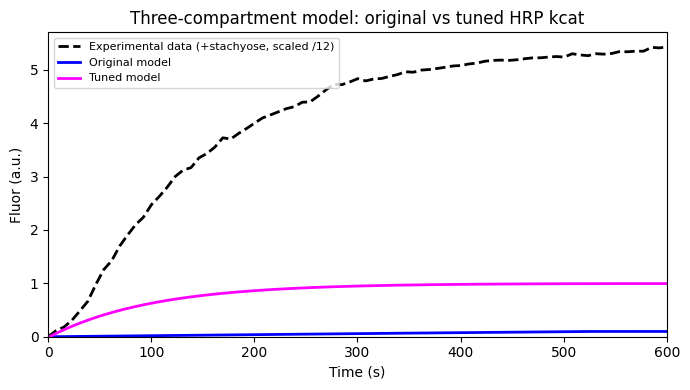

Saved: tuning_figures/fig_2B_tuned_GOx_kcat.png


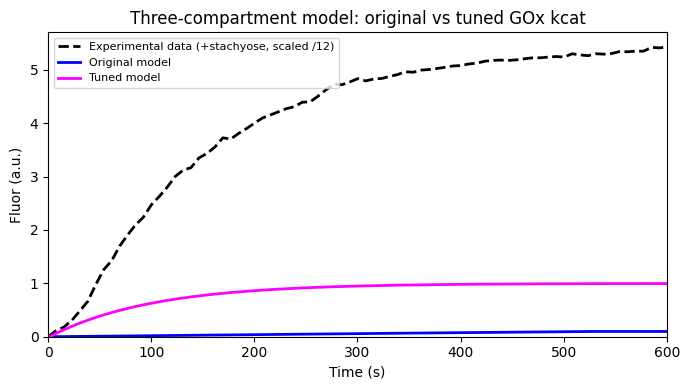

Saved: tuning_figures/fig_2C_tuned_diffusion_10x.png


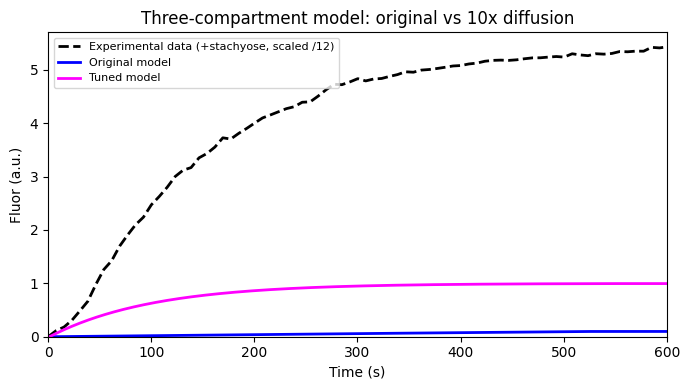

Saved: tuning_figures/fig_2D_tuned_diffusion_50x.png


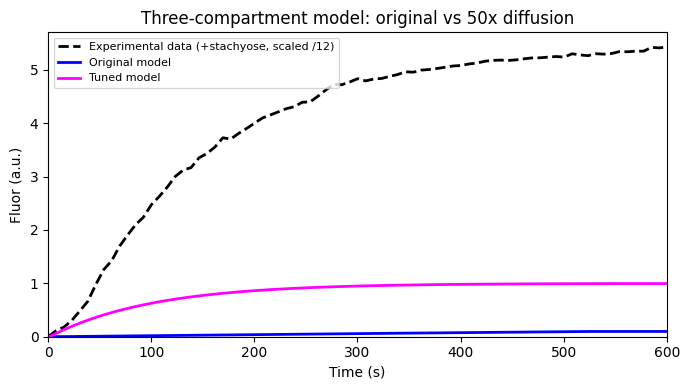

Saved: tuning_figures/fig_2E_tuned_diffusion_100x.png


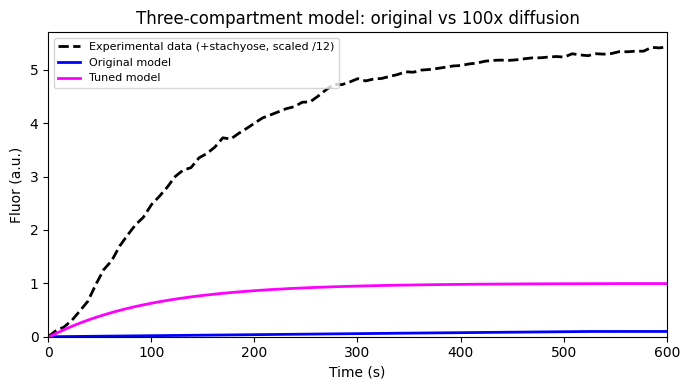

Saved: tuning_figures/fig_2F_tuned_diffusion_500x.png


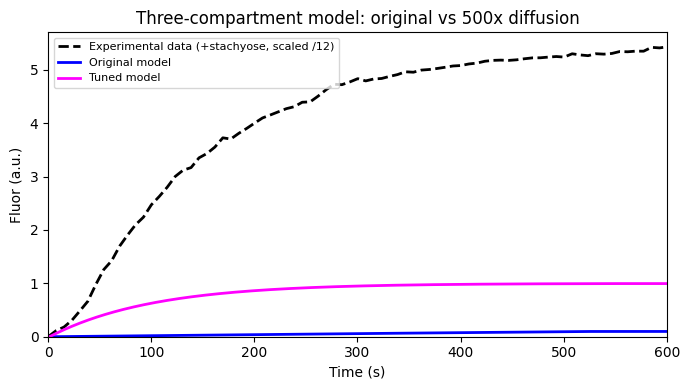

Saved: tuning_figures/fig_2G_tuned_diffusion_100x_HRP_10x.png


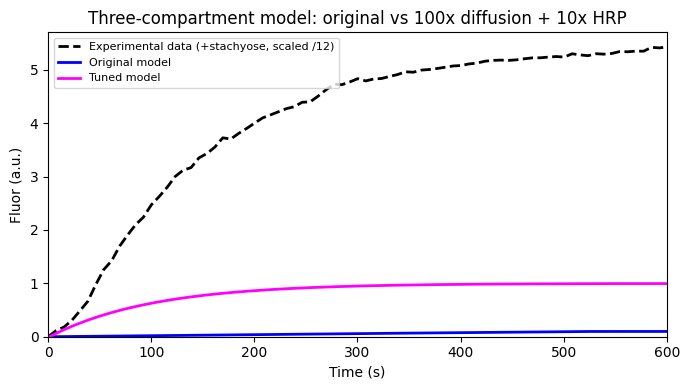

Saved: tuning_figures/fig_2H_tuned_diffusion_100x_GOx_10x.png


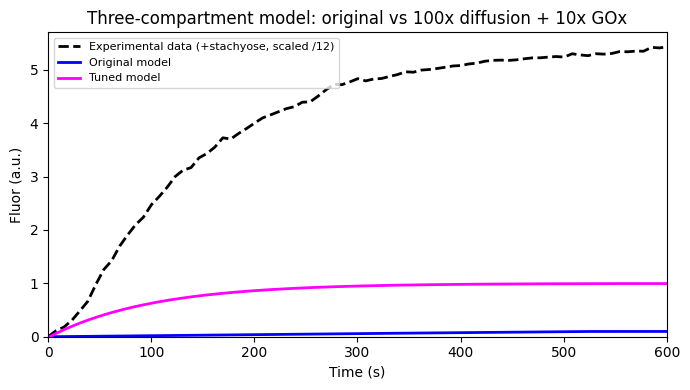

Saved: tuning_figures/fig_2I_tuned_membrane_transport_10x.png


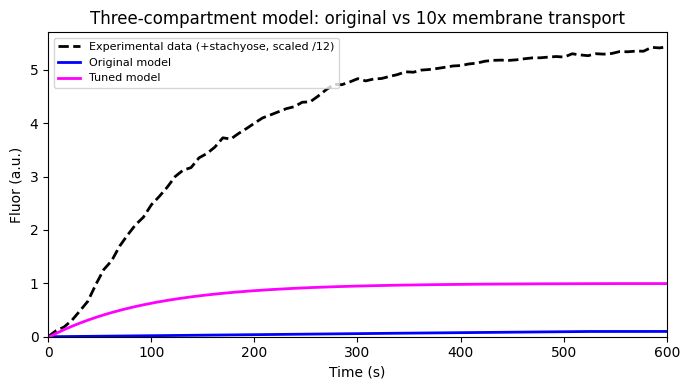

In [55]:
# note:
# Save static PNG versions of the tuning plots.
import os
import matplotlib.pyplot as plt

TUNING_FIG_DIR = "tuning_figures"
os.makedirs(TUNING_FIG_DIR, exist_ok=True)


def save_tuning_plot(original_results, tuned_results, title, filename):
    """
    Save one tuning comparison plot as a static PNG.
    Shows experimental data, original model, and tuned model on the same scale.
    """

    orig_time_col = find_col(original_results, "time")
    orig_res_col = find_col(original_results, "resorufin")

    tuned_time_col = find_col(tuned_results, "time")
    tuned_res_col = find_col(tuned_results, "resorufin")

    fig, ax = plt.subplots(figsize=(7, 4))

    # experimental data
    ax.plot(
        time3,
        data3_scaled,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Experimental data (+stachyose, scaled /12)"
    )

    # original model
    ax.plot(
        original_results[orig_time_col],
        original_results[orig_res_col],
        color="blue",
        linewidth=2,
        label="Original model"
    )

    # tuned model
    ax.plot(
        tuned_results[tuned_time_col],
        tuned_results[tuned_res_col],
        color="magenta",
        linewidth=2,
        label="Tuned model"
    )

    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fluor (a.u.)")
    ax.set_xlim(0, 600)

    ymax = max(
        data3_scaled.max(),
        original_results[orig_res_col].max(),
        tuned_results[tuned_res_col].max()
    ) * 1.05

    ax.set_ylim(0, ymax)
    ax.legend(loc="upper left", fontsize=8)

    fig.tight_layout()

    path = os.path.join(TUNING_FIG_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

    plt.show()


tuning_plot_cases = [
    (
        "tuned_results",
        "Three-compartment model: original vs tuned HRP kcat",
        "fig_2A_tuned_HRP_kcat.png"
    ),
    (
        "gox_results",
        "Three-compartment model: original vs tuned GOx kcat",
        "fig_2B_tuned_GOx_kcat.png"
    ),
    (
        "diffusion_results",
        "Three-compartment model: original vs 10x diffusion",
        "fig_2C_tuned_diffusion_10x.png"
    ),
    (
        "diffusion_50x_results",
        "Three-compartment model: original vs 50x diffusion",
        "fig_2D_tuned_diffusion_50x.png"
    ),
    (
        "diffusion_100x_results",
        "Three-compartment model: original vs 100x diffusion",
        "fig_2E_tuned_diffusion_100x.png"
    ),
    (
        "diffusion_500x_results",
        "Three-compartment model: original vs 500x diffusion",
        "fig_2F_tuned_diffusion_500x.png"
    ),
    (
        "combined_results",
        "Three-compartment model: original vs 100x diffusion + 10x HRP",
        "fig_2G_tuned_diffusion_100x_HRP_10x.png"
    ),
    (
        "gox_diffusion_results",
        "Three-compartment model: original vs 100x diffusion + 10x GOx",
        "fig_2H_tuned_diffusion_100x_GOx_10x.png"
    ),
    (
        "transport_results",
        "Three-compartment model: original vs 10x membrane transport",
        "fig_2I_tuned_membrane_transport_10x.png"
    ),
]


for results_variable, title, filename in tuning_plot_cases:
    if results_variable in globals():
        save_tuning_plot(
            original_results=original_results,
            tuned_results=globals()[results_variable],
            title=title,
            filename=filename
        )
    else:
        print("Skipped missing results variable:", results_variable)